In [1]:
import os
import copy
import numpy as np
import pandas as pd 
from dekef.base_density import *
from dekef.kernel_function import *
from dekef.ortho_proj_hatz import hatz
from IFlogdensity.influence_function_sm_de import plot_IF_1d_params
from IFlogdensity.contam_sm_de_finkernelexpfam import *
import seaborn as sns

import matplotlib.pyplot as plt 

from datetime import datetime as dt

import matplotlib.gridspec as gridspec

In [5]:
# os.chdir('../')
true_data = np.load('../data/geyser.npy').astype(np.float64)
df = copy.deepcopy(true_data[:, 0]).reshape(-1, 1)

# # original data with 108.0 removed
data_waiting = df[df != 108.0]
# data_waiting = df

# array of contaminated data
contam_data_list = np.array([20.]).reshape(-1, 1) # np.arange(20., 182., 2).reshape(-1, 1)

# kernel function used
kernel_type = 'gaussian_poly2'

# bandwidth parameter in the Gaussian kernel function
bw = 5.0

k_folds = 3

seed_num = 29
# 893371436, 1405289136,  221902869, 2241142843,  354926085, 
# 2368900135, 2773632455, 2723165907,  572329693, 3793478080,
# 1238921510,  234059118, 2664351965,  655848720, 3958505628,
# 3332268999, 1191655600,  818578564,  401340103, 1
# 170, 644, 429, 948, 111, 
# 362, 259, 652, 29, 178

seed_num_list = [893371436, 1405289136,  221902869, 2241142843,  354926085, 
                 2368900135, 2773632455, 2723165907,  572329693, 3793478080,
                 1238921510,  234059118, 2664351965,  655848720, 3958505628,
                 3332268999, 1191655600,  818578564,  401340103, 1, 
                 170, 644, 429, 948, 111, 362, 259, 652, 29, 178]

# base density
base_density = BasedenGamma(data_waiting, a = 36., scale = 2.)
# base_density = BasedenUniform(data_waiting, domain = [[0., 310.]])

# penalty parameter
log_pen_param_list = np.arange(-10., -5., 0.5)

In [6]:
plot_kwargs = plot_IF_1d_params(x_limit=(1., 210.), plot_pts_cnt=3000)
plot_xlimit = plot_kwargs['x_limit']
plot_pts_cnt = plot_kwargs['plot_pts_cnt']

new_data = np.linspace(plot_xlimit[0], plot_xlimit[1], plot_pts_cnt)

In [7]:
# full_save_folder = (f'../data/PenSM-FinKEF-data=waiting-bw={bw}-kernel={kernel_type}-' +
#                     f'empirical-inf-fun-plotdomain={plot_xlimit}-plotcnts={plot_pts_cnt}' + 
#                     f'-baseden=gamma-{base_density.a}-{base_density.scale}-grid_points=1-202-1-cross-validation')
# if not os.path.isdir(full_save_folder):
#     os.mkdir(full_save_folder)

**************************************************
log penalty = -10.0
**************************************************
log penalty = -9.5
**************************************************
log penalty = -9.0
**************************************************
log penalty = -8.5
**************************************************
log penalty = -8.0
**************************************************
log penalty = -7.5
**************************************************
log penalty = -7.0
**************************************************
log penalty = -6.5
**************************************************
log penalty = -6.0
**************************************************
log penalty = -5.5
scores with no contamination: [-0.01258098 -0.01264089 -0.01255217 -0.01235973 -0.01207146 -0.01166536
 -0.01110139 -0.0103213  -0.00926147 -0.00790741]
--------------------------------------------------
The optimal penalty parameter without contamination is -9.5.


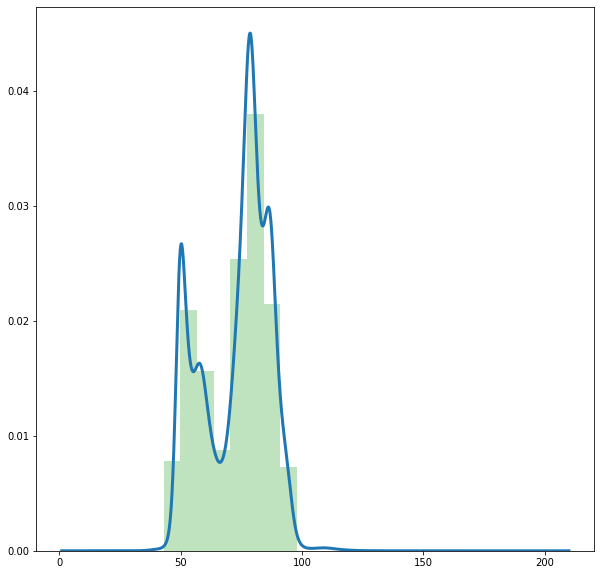

uncontam_norm = 7.259618950669334


In [8]:
# compute the cross-validated density estimator under F_{n}
r1, r2, c = 1., 0., 0.

N = data_waiting.shape[0]

j = 0
sm_scores_uncontam = np.zeros((len(log_pen_param_list),), dtype = np.float64)

for log_pen_param in log_pen_param_list:

    print('*' * 50)
    print(f'log penalty = {log_pen_param}')

    grid_points = np.arange(1., 202., 1).reshape(-1, 1)
    # print(grid_points.flatten())

    # cross validation 
    np.random.seed(seed_num)
    folds_i = np.random.randint(low = 0, high = k_folds, size = N)

    score_uncontam = 0.

    for i in range(k_folds):

        # data split
        train_data = data_waiting[folds_i != i, ]
        test_data = data_waiting[folds_i == i, ]

        # ------------------------------------------------------------
        # uncontaminated data 
        uncontam_sm = ContamSMFinKernelExpFam(
            data = train_data,
            contam_data = contam_data_list[0].reshape(-1, 1),
            grid_points = grid_points,
            contam_weight = 0.,
            penalty_param = np.exp(log_pen_param),
            base_density = base_density,
            r1 = r1,
            r2 = r2,
            c = c,
            bw = bw,
            kernel_type = 'gaussian_poly2')

        coef_uncontam = uncontam_sm.coef()

        # evaluate the score matching loss function
        kernel_function_test = GaussianPoly2(
            data=test_data,
            r1=r1,
            r2=r2,
            c=c,
            bw=bw)

        matg = kernel_function_test.partial_kernel_matrix_10(grid_points).T

        t_vec = hatz(
            data=test_data,
            new_data=grid_points,
            kernel_function=kernel_function_test,
            base_density=base_density
        ).reshape(-1, 1)

        loss1 = coef_uncontam.T @ (matg @ matg.T / len(test_data)) @ coef_uncontam / 2. - coef_uncontam.T @ t_vec

        score_uncontam += loss1.item()

    sm_scores_uncontam[j, ] = score_uncontam / k_folds
    j += 1

print(f'scores with no contamination: {sm_scores_uncontam}')

print('-' * 50)

# find the optimal regularization parameter
opt_loglambda_uncontam = log_pen_param_list[np.argmin(sm_scores_uncontam)]

print("The optimal penalty parameter without contamination is {}.".format(opt_loglambda_uncontam))

# run with all data 
# uncontaminated data 
uncontam_sm = ContamSMFinKernelExpFam(
    data = data_waiting,
    contam_data = contam_data_list[0].reshape(-1, 1),
    grid_points = grid_points,
    contam_weight = 0.,
    penalty_param = np.exp(opt_loglambda_uncontam),
    base_density = base_density,
    r1 = r1,
    r2 = r2,
    c = c,
    bw = bw,
    kernel_type = 'gaussian_poly2')

coef_uncontam = uncontam_sm.coef()

gram_mat = uncontam_sm.gram_matrix
uncontam_norm = np.sqrt(coef_uncontam.T @ gram_mat @ coef_uncontam).item()
uncontam_logden_vals = uncontam_sm.log_density(new_data, coef_uncontam, True)

plt.figure(figsize = (10, 10))
plt.plot(new_data, np.exp(uncontam_logden_vals), color = 'tab:blue', lw = 3.0)
plt.hist(data_waiting, bins='fd', density = True, alpha = 0.3, color = 'tab:green')
plt.show()

# file_name_newdata = f'/new_data.npy'
# np.save(full_save_folder + file_name_newdata, new_data)

# file_name_coef = f'/seed={seed_num}-folds={k_folds}-CV-uncontam-coef.npy'
# np.save(full_save_folder + file_name_coef, coef_uncontam)

# file_name_diff = f'/seed={seed_num}-folds={k_folds}-CV-uncontam-logden-newdata.npy'
# np.save(full_save_folder + file_name_diff, uncontam_logden_vals)

print(f'uncontam_norm = {uncontam_norm}')


start time = 10:42:03
contam data = 20.0
log penalty = -10.0
log penalty = -9.5
log penalty = -9.0
log penalty = -8.5
log penalty = -8.0
log penalty = -7.5
log penalty = -7.0
log penalty = -6.5
log penalty = -6.0
log penalty = -5.5
--------------------------------------------------
The optimal penalty parameter with contamination 20.0 is -9.5.


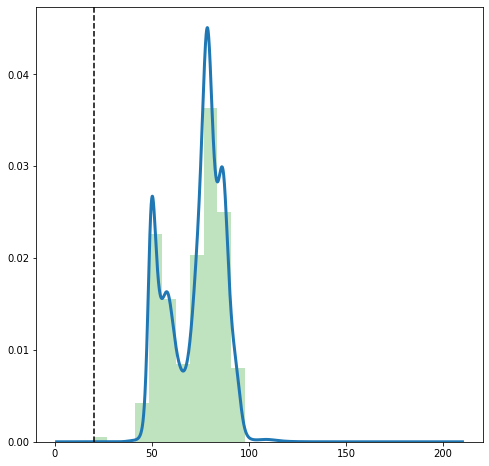

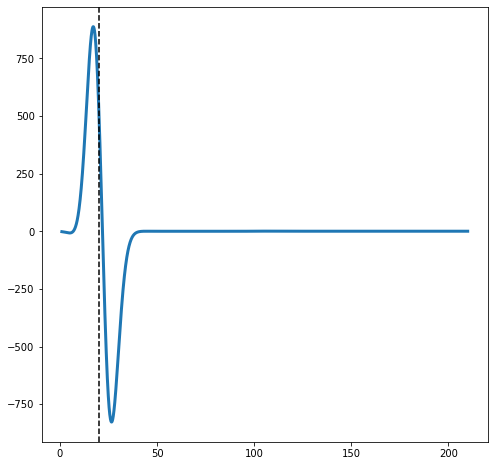

887.358624604298
end time = 10:42:26


In [10]:
# compute the cross-validated density estimator under F_{n+1}
r1, r2, c = 1., 0., 0.

result1 = []

N = data_waiting.shape[0]

for contam_data1 in contam_data_list: 
    
    print(f'start time = {dt.now().strftime("%H:%M:%S")}')
    
    j = 0
    sm_scores_contam = np.zeros((len(log_pen_param_list),), dtype = np.float64)
    
    print('=' * 80)
    print(f'contam data = {contam_data1.item()}')
    
    data_waiting2 = np.append(data_waiting, contam_data1.item())

    for log_pen_param in log_pen_param_list:
        
        print(f'log penalty = {log_pen_param}')

        grid_points = np.arange(1., 202., 1).reshape(-1, 1)
        
        # cross validation 
        np.random.seed(seed_num)
        folds_i = np.random.randint(low = 0, high=k_folds, size = N + 1)

        score_contam = 0.

        for i in range(k_folds):

            # data split
            train_data = data_waiting2[folds_i != i, ]
            test_data = data_waiting2[folds_i == i, ]

            # ------------------------------------------------------------
            # contaminated data 
            contam_sm = ContamSMFinKernelExpFam(
                data=train_data,
                contam_data=contam_data_list[0].reshape(-1, 1),
                grid_points=grid_points,
                contam_weight=0.,
                penalty_param=np.exp(log_pen_param),
                base_density=base_density,
                r1=r1,
                r2=r2,
                c=c,
                bw=bw,
                kernel_type='gaussian_poly2')

            coef_contam = contam_sm.coef()

            # evaluate the score matching loss function
            kernel_function_test = GaussianPoly2(
                data=test_data,
                r1=r1,
                r2=r2,
                c=c,
                bw=bw)

            matg = kernel_function_test.partial_kernel_matrix_10(grid_points).T

            t_vec = hatz(
                data=test_data,
                new_data=grid_points,
                kernel_function=kernel_function_test,
                base_density=base_density
            ).reshape(-1, 1)

            loss2 = coef_contam.T @ (matg @ matg.T / len(test_data)) @ coef_contam / 2. - coef_contam.T @ t_vec

            score_contam += loss2.item()

        sm_scores_contam[j, ] = score_contam / k_folds
        j += 1
        
    # print(f'scores with contamination: {sm_scores_contam}')

    print('-' * 50)

    # find the optimal regularization parameter
    opt_loglambda_contam = log_pen_param_list[np.argmin(sm_scores_contam)]
    
    print("The optimal penalty parameter with contamination {l1} is {l2}.".format(
        l1 = contam_data1.item(), l2 = opt_loglambda_contam))

    # run with all data 
    # contaminated data 
    contam_sm = ContamSMFinKernelExpFam(
        data=data_waiting2,
        contam_data=contam_data_list[0].reshape(-1, 1),
        grid_points=grid_points,
        contam_weight=0.,
        penalty_param=np.exp(opt_loglambda_contam),
        base_density=base_density,
        r1=r1,
        r2=r2,
        c=c,
        bw=bw,
        kernel_type='gaussian_poly2')

    coef_contam = contam_sm.coef()

    gram_mat = contam_sm.gram_matrix
    contam_norm = np.sqrt(coef_contam.T @ gram_mat @ coef_contam).item()
    contam_logden_vals = contam_sm.log_density(new_data, coef_contam, True)

    plt.figure(figsize = (8, 8))
    plt.plot(new_data, np.exp(contam_logden_vals), color = 'tab:blue', lw = 3.0)
    plt.hist(data_waiting2, bins='fd', density = True, alpha = 0.3, color = 'tab:green')
    plt.axvline(x = contam_data1.item(), color = 'k', linestyle='--')
    plt.show()
    
    IF_vals = (contam_logden_vals - uncontam_logden_vals) * (N + 1)

    plt.figure(figsize = (8, 8))
    plt.plot(new_data, IF_vals, color = 'tab:blue', lw = 3.0)
    plt.axvline(x = contam_data1.item(), color = 'k', linestyle='--')
    plt.show()

#     file_name_coef = f'/seed={seed_num}-folds={k_folds}-contamdata={contam_data1.item()}-CV-contam-coef.npy'
#     np.save(full_save_folder + file_name_coef, coef_contam)

#     file_name_diff = f'/seed={seed_num}-folds={k_folds}-contamdata={contam_data1.item()}-CV-contam-logden-newdata.npy'
#     np.save(full_save_folder + file_name_diff, contam_logden_vals)
    
#     file_name_IF = f'/seed={seed_num}-folds={k_folds}-contamdata={contam_data1.item()}-CV-contam-IFvals-newdata.npy'
#     np.save(full_save_folder + file_name_IF, IF_vals)

    print(np.max(IF_vals))
    
    result1.append([seed_num, contam_data1.item(), opt_loglambda_uncontam, uncontam_norm, 
                    opt_loglambda_contam, contam_norm, np.max(IF_vals), np.max(np.abs(IF_vals))])
    
    print(f'end time = {dt.now().strftime("%H:%M:%S")}')

In [ ]:
# pd.DataFrame(result1, columns = ['seed_num', 'contam_data', 'opt_loglambda_uncontam', 'uncontam_norm', 
#                                  'opt_loglambda_contam', 'contam_norm', 'IF_sup_pos', 'IF_sup']).to_csv(
#     f'/Users/chenxizhou/Desktop/seed-{seed_num}-fold-{k_folds}.csv')

## Make plots 

In [ ]:
seed_num_list = [893371436, 1405289136,  221902869, 2241142843,  354926085, 
                 2368900135, 2773632455, 2723165907,  572329693, 3793478080,
                 1238921510,  234059118, 2664351965,  655848720, 3958505628,
                 3332268999, 1191655600,  818578564,  401340103, 1, 
                 170, 644, 429, 948, 111, 362, 259, 652, 29, 178]
avoid = 1405289136

seed_num_list = [i for i in seed_num_list if i != avoid]

In [ ]:
plot_kwargs = plot_IF_1d_params(x_limit=(1., 210.), plot_pts_cnt=3000)
plot_xlimit = plot_kwargs['x_limit']
plot_pts_cnt = plot_kwargs['plot_pts_cnt']

full_save_folder = (f'data/PenSM-FinKEF-data=waiting-bw={bw}-kernel={kernel_type}-' +
                    f'empirical-inf-fun-plotdomain={plot_xlimit}-plotcnts={plot_pts_cnt}' + 
                    f'-baseden=gamma-{base_density.a}-{base_density.scale}-grid_points=1-202-1-cross-validation')

In [ ]:
cv_summary_folder = full_save_folder + '/data-summary-files'
final_df = pd.DataFrame({})

k_folds = 10

for seed_num in seed_num_list: 
    
    
    
    temp = pd.read_csv(cv_summary_folder + f'/seed-{seed_num}-fold-{k_folds}.csv', 
                       usecols = ['seed_num', 'contam_data', 'opt_loglambda_uncontam', 'uncontam_norm', 
                                 'opt_loglambda_contam', 'contam_norm', 'IF_sup_pos', 'IF_sup'])
    final_df = pd.concat([final_df, temp], axis = 0)

In [ ]:
final_df3 = final_df
final_df3.to_csv('data/cv-3.csv')

In [ ]:
final_df5 = final_df
final_df5.to_csv('data/cv-5.csv')

In [ ]:
final_df10 = final_df
final_df10.to_csv('data/cv-10.csv')

In [ ]:
info_coord = (0.035, 0.035)
horizontalalignment, verticalalignment = 'left', 'top'

label_fontsize = 30
info_fontsize = 35
tick_fontsize = 25
legend_fontsize = 25
linewidth = 4.0
x_label = r'$y$'
y_label = r'overall influence'

nrows = 1
ncols = 3

xlim = (15., 185.)
ylim = (-50., 1110.)

info_coord = (0.98, 0.98)

fig = plt.figure(figsize=(30, 10))
gs = gridspec.GridSpec(nrows = nrows, ncols = ncols)

color = 'green'

xticks = [20, 40, 60, 80, 100, 120, 140, 160, 180]
yticks = [0, 200, 400, 600, 800, 1000, 1200]

# 3 fold
ax1 = fig.add_subplot(gs[0, 0])

df = final_df3
plot_data = [df[df.contam_data == contam_data].IF_sup.to_list() for contam_data in contam_data_list.flatten()]

ax1.boxplot(plot_data, 0, 'k.', 
           widths = 1., 
           positions = contam_data_list.flatten())

ax1.set_xlim(xlim)
ax1.set_ylim(ylim)

ax1.set_xticks(xticks)
ax1.set_xticklabels(xticks, size = tick_fontsize)

ax1.set_xlabel(x_label, fontsize = label_fontsize)
ax1.set_ylabel(y_label, fontsize = label_fontsize)
ax1.tick_params(axis = 'both', labelsize = tick_fontsize)
sns.rugplot(pd.Series(data_waiting.flatten()), ax = ax1, color = 'black')

info = 'Number of folds = 3'
ax1.text(*info_coord,
        info,
        fontsize = info_fontsize,
        multialignment = 'left',
        horizontalalignment = 'right',
        verticalalignment = 'top',
        transform = ax1.transAxes,
        bbox = {'facecolor': 'none',
                'boxstyle': 'Round, pad=0.2'})

# 5 fold
ax = fig.add_subplot(gs[0, 1], sharey = ax1)

df = final_df5
plot_data = [df[df.contam_data == contam_data].IF_sup.to_list() for contam_data in contam_data_list.flatten()]

ax.boxplot(plot_data, 0, 'k.', 
           widths = 1., 
           positions = contam_data_list.flatten())

ax.set_xlim(xlim)
ax.set_yticks(yticks)
ax.set_yticklabels(yticks, size = tick_fontsize)

ax.set_xticks(xticks)
ax.set_xticklabels(xticks, size = tick_fontsize)

ax.set_xlabel(x_label, fontsize = label_fontsize)
# ax.set_ylabel(y_label, fontsize = label_fontsize)

plt.setp(ax.get_yticklabels(), visible=False)

ax.tick_params(axis = 'x', labelsize = tick_fontsize)
sns.rugplot(pd.Series(data_waiting.flatten()), ax = ax, color = 'black')

info = 'Number of folds = 5'
ax.text(*info_coord,
        info,
        fontsize = info_fontsize,
        multialignment = 'left',
        horizontalalignment = 'right',
        verticalalignment = 'top',
        transform = ax.transAxes,
        bbox = {'facecolor': 'none',
                'boxstyle': 'Round, pad=0.2'})

# 10 fold
ax = fig.add_subplot(gs[0, 2], sharey = ax1)

df = final_df10
plot_data = [df[df.contam_data == contam_data].IF_sup.to_list() for contam_data in contam_data_list.flatten()]

ax.boxplot(plot_data, 0, 'k.', 
           widths = 1., 
           positions = contam_data_list.flatten())

ax.set_xlim(xlim)
ax.set_xticks(xticks)
ax.set_xticklabels(xticks, size = tick_fontsize)

plt.setp(ax.get_yticklabels(), visible=False)

ax.set_xlabel(x_label, fontsize = label_fontsize)
# ax.set_ylabel(y_label, fontsize = label_fontsize)
ax.tick_params(axis = 'both', labelsize = tick_fontsize)
sns.rugplot(pd.Series(data_waiting.flatten()), ax = ax, color = 'black')

info = 'Number of folds = 10'
ax.text(*info_coord,
        info,
        fontsize = info_fontsize,
        multialignment = 'left',
        horizontalalignment = 'right',
        verticalalignment = 'top',
        transform = ax.transAxes,
        bbox = {'facecolor': 'none',
                'boxstyle': 'Round, pad=0.2'})

plt.tight_layout()

plt.savefig(f'plots/PenSMFin-geyser-waiting-overall-emp-influence-y-baseden=Gamma-{base_density.a}-{base_density.scale}-gridpoints=1-202-1-cross-validation.pdf', 
            bbox_inches = 'tight')

plt.show()
